In [ ]:
import warnings

from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")
import torch

import pandas as pd
import numpy as np
import scanpy as sc
import os
import yaml
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ['R_HOME'] = '/home/anaconda3/envs/SpaDAR/lib/R'
os.environ['R_USER'] = '/home/anaconda3/envs/SpaDAR/lib/site-packages/rpy2'
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.decomposition import PCA

import os
import sys

current_dir = os.getcwd() 

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 现在尝试导入
try:
    import SpaDAR as TOOLS
except ModuleNotFoundError:
    print("❌ 依然找不到 SpaDAR，请确认当前工作目录是否正确。")
    print(f"当前搜索路径: {current_dir}")

In [2]:
# %%
with open('../Config/STARmap.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

In [ ]:
adata = sc.read_h5ad(r"/home/SpaDAR/data_zip/STARmap Mouse visual cortex/STARmap_mouse_visual_cortex/STARmap_20180505_BY3_1k.h5ad")
adata.var_names_make_unique()

adata.obs['layer_guess'] = adata.obs['label']

edge_index = TOOLS.graph_construction(adata, config['data']['k_cutoff'])

adata.layers['count'] = adata.X
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=config['data']['top_genes'])
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [4]:
num_clusters = 7
# %%
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
net = TOOLS.SC_pipeline(adata, edge_index=edge_index, num_clusters=num_clusters, device=device, config=config,
                 imputation=False)
# %%
net.trian()
# %%
enc_rep, recon = net.process()
adata.obsm['latent'] = enc_rep

Epoch 299 total loss=1.032 recon loss=1.090 mean loss=0.343 tri loss=1.375: 100%|██████████| 300/300 [00:35<00:00,  8.42it/s]


In [5]:
clusType = 'mclust'
# %%
adata.obs[clusType] = TOOLS.clustering(z=enc_rep, n_clust=num_clusters, num_seed=1, method=clusType)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [6]:
ARI, ACC, DIS = TOOLS.get_metrics(adata, 'layer_guess', clusType)
print(f"ARI: {round(ARI, 4)} ACC: {round(ACC, 4)} DIS: {round(DIS, 4)}")

ARI: 0.6819 ACC: 0.7333 DIS: 0.0388


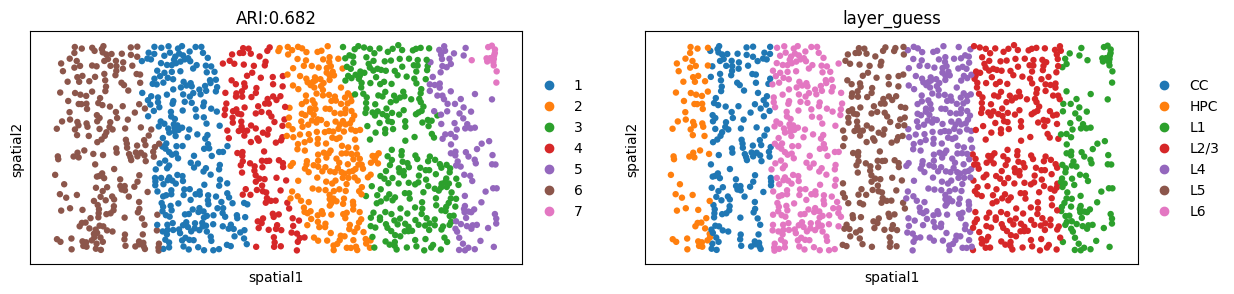

In [7]:
sc.pl.spatial(adata, color=[clusType,'layer_guess'],
              title='ARI:' + str(round(ARI, 3)), show=True, spot_size=200, save=False)